# March Machine Learning Mania 2026 — Analysis Notebook
**Team Members:** Samuel Turner, Rishi Vaddiraju

**Goal:** Predict the probability that Team A beats Team B in NCAA Men's Tournament matchups.

**Evaluation Metric:** Log Loss

In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score, roc_auc_score

DATA_DIR = './'
RANDOM_STATE = 42

## 1. Load Data

In [80]:
reg_detailed = pd.read_csv(DATA_DIR + 'MRegularSeasonDetailedResults.csv')
reg_compact = pd.read_csv(DATA_DIR + 'MRegularSeasonCompactResults.csv')
tourney_results = pd.read_csv(DATA_DIR + 'MNCAATourneyCompactResults.csv')
seeds = pd.read_csv(DATA_DIR + 'MNCAATourneySeeds.csv')
team_conferences = pd.read_csv(DATA_DIR + 'MTeamConferences.csv')

print('Regular season detailed results:')
print(reg_detailed.info())


Regular season detailed results:
<class 'pandas.DataFrame'>
RangeIndex: 124529 entries, 0 to 124528
Data columns (total 34 columns):
 #   Column   Non-Null Count   Dtype
---  ------   --------------   -----
 0   Season   124529 non-null  int64
 1   DayNum   124529 non-null  int64
 2   WTeamID  124529 non-null  int64
 3   WScore   124529 non-null  int64
 4   LTeamID  124529 non-null  int64
 5   LScore   124529 non-null  int64
 6   WLoc     124529 non-null  str  
 7   NumOT    124529 non-null  int64
 8   WFGM     124529 non-null  int64
 9   WFGA     124529 non-null  int64
 10  WFGM3    124529 non-null  int64
 11  WFGA3    124529 non-null  int64
 12  WFTM     124529 non-null  int64
 13  WFTA     124529 non-null  int64
 14  WOR      124529 non-null  int64
 15  WDR      124529 non-null  int64
 16  WAst     124529 non-null  int64
 17  WTO      124529 non-null  int64
 18  WStl     124529 non-null  int64
 19  WBlk     124529 non-null  int64
 20  WPF      124529 non-null  int64
 21  LFGM     12

In [81]:
reg_detailed.head()

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WFGM,WFGA,...,LFGA3,LFTM,LFTA,LOR,LDR,LAst,LTO,LStl,LBlk,LPF
0,2003,10,1104,68,1328,62,N,0,27,58,...,10,16,22,10,22,8,18,9,2,20
1,2003,10,1272,70,1393,63,N,0,26,62,...,24,9,20,20,25,7,12,8,6,16
2,2003,11,1266,73,1437,61,N,0,24,58,...,26,14,23,31,22,9,12,2,5,23
3,2003,11,1296,56,1457,50,N,0,18,38,...,22,8,15,17,20,9,19,4,3,23
4,2003,11,1400,77,1208,71,N,0,30,61,...,16,17,27,21,15,12,10,7,1,14


## 2. Pre-processing

#### Missing Values

In [82]:
##Check missing values across all loaded files
for name, df in [('reg_detailed', reg_detailed), ('tourney_results', tourney_results),
                 ('seeds', seeds), ('team_conferences', team_conferences)]:
    missing = df.isnull().sum().sum()
    print(f'{name:25s}: {missing} missing values')

reg_detailed             : 0 missing values
tourney_results          : 0 missing values
seeds                    : 0 missing values
team_conferences         : 0 missing values


#### Filter to 2003+ (detailed box score stats only available from 2003 onward)

In [83]:
START_SEASON = 2003
reg_detailed = reg_detailed[reg_detailed.Season >= START_SEASON].copy()
reg_compact = reg_compact[reg_compact.Season >= START_SEASON].copy()
tourney_results = tourney_results[tourney_results.Season >= START_SEASON].copy()
seeds = seeds[seeds.Season >= START_SEASON].copy()
team_conferences = team_conferences[team_conferences.Season >= START_SEASON].copy()

##Encode conference as integer category
team_conferences['ConfCode'] = pd.Categorical(team_conferences['ConfAbbrev']).codes

print(f'Regular season games : {len(reg_detailed):,}')
print(f'Tournament games: {len(tourney_results):,}')
print(f'Seasons covered: {reg_detailed.Season.min()} – {reg_detailed.Season.max()}')


Regular season games : 124,529
Tournament games: 1,449
Seasons covered: 2003 – 2026


#### Parse seed strings into numeric seed numbers

In [84]:
##Seed strings look like "W01", "X16a" — extract the number
seeds['SeedNum'] = seeds['Seed'].str.extract(r'(\d+)').astype(int)
seeds.head()

,Season,Seed,TeamID,SeedNum
1154,2003,W01,1328,1
1155,2003,W02,1448,2
1156,2003,W03,1393,3
1157,2003,W04,1257,4
1158,2003,W05,1280,5


## 3. Distribution Analysis

#### Target variable: winning vs. losing scores

            WScore       LScore
count  1449.000000  1449.000000
mean     75.648723    63.908903
std      10.757312    10.380668
min      47.000000    29.000000
25%      68.000000    57.000000
50%      75.000000    64.000000
75%      83.000000    71.000000
max     121.000000   105.000000


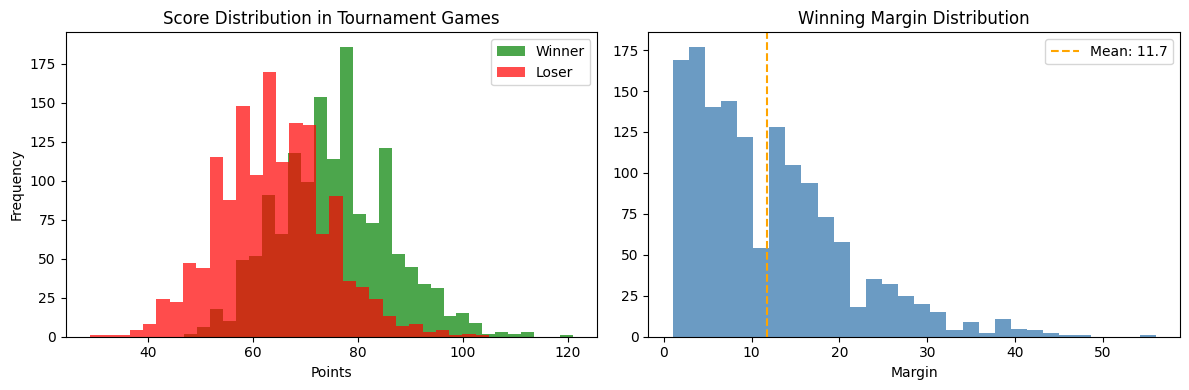

In [85]:
print(tourney_results[['WScore', 'LScore']].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(tourney_results['WScore'], bins=30, alpha=0.7, label='Winner', color='green')
axes[0].hist(tourney_results['LScore'], bins=30, alpha=0.7, label='Loser', color='red')
axes[0].set_title('Score Distribution in Tournament Games')
axes[0].set_xlabel('Points'); axes[0].set_ylabel('Frequency')
axes[0].legend()

margin = tourney_results['WScore'] - tourney_results['LScore']
axes[1].hist(margin, bins=30, color='steelblue', alpha=0.8)
axes[1].axvline(margin.mean(), color='orange', linestyle='--', label=f'Mean: {margin.mean():.1f}')
axes[1].set_title('Winning Margin Distribution')
axes[1].set_xlabel('Margin'); axes[1].legend()

plt.tight_layout()
plt.show()

#### Distribution of numeric features (regular season box scores)

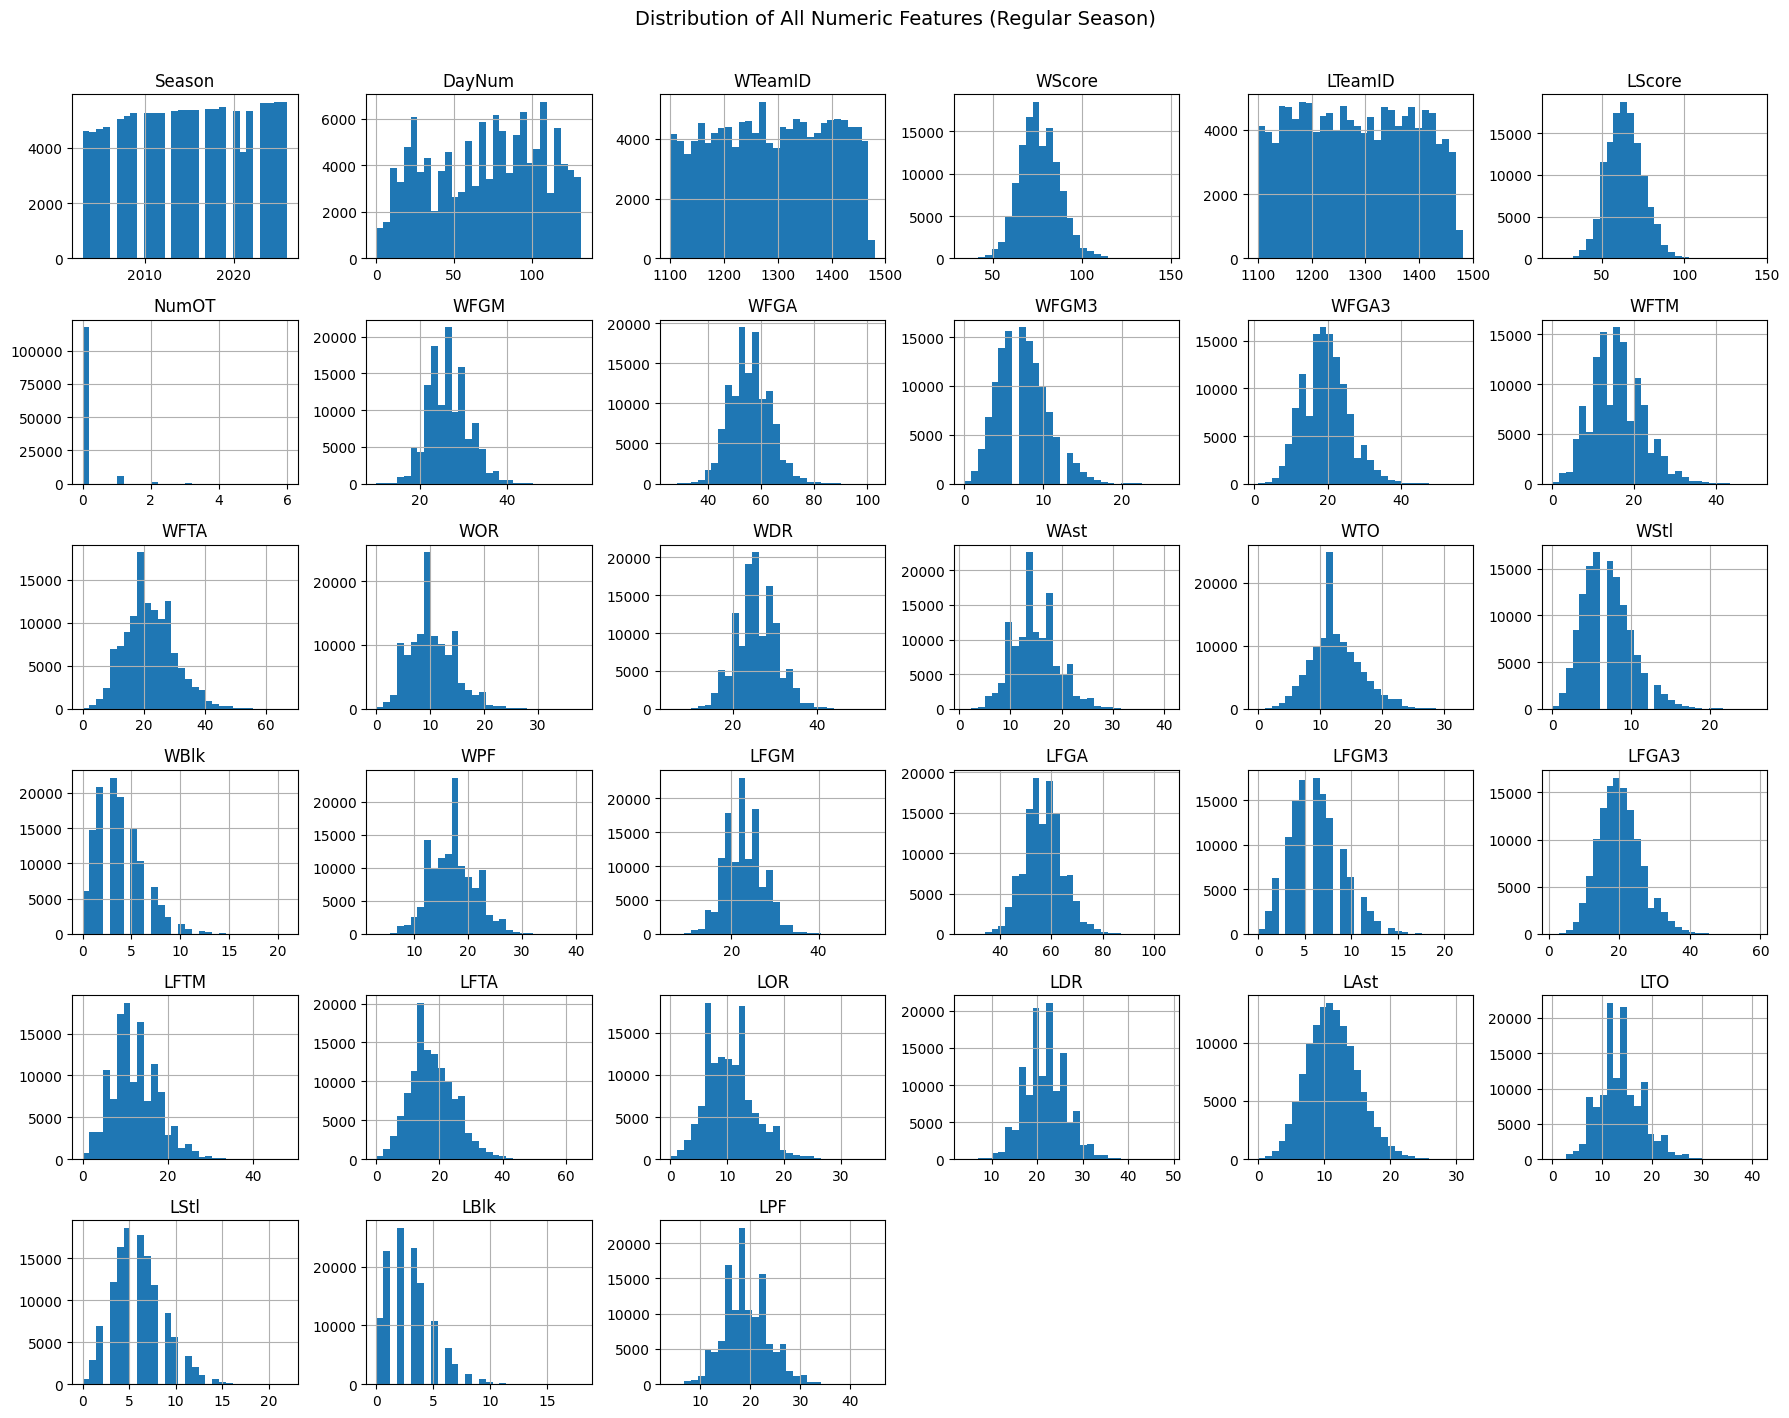

In [86]:
reg_detailed.select_dtypes(include='number').hist(figsize=(18, 14), bins=30)
plt.suptitle('Distribution of All Numeric Features (Regular Season)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

#### Seed win rate analysis

Overall upset rate (main draw): 28.7%


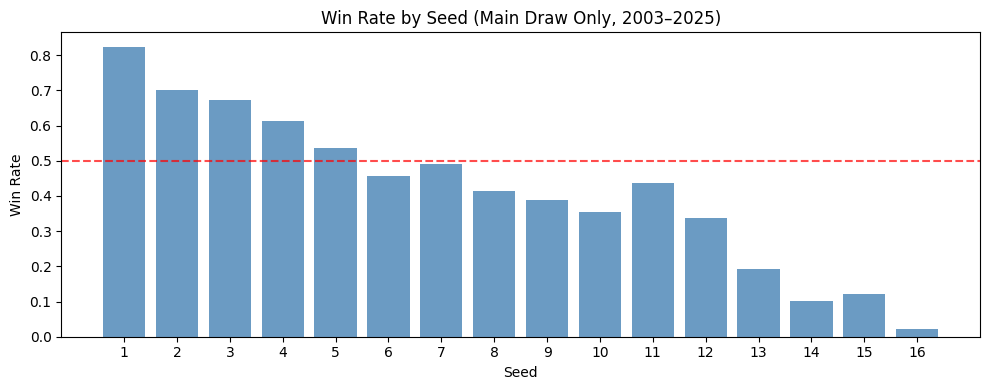

In [87]:
##Merge seeds onto tournament results
tourney_w_seeds = tourney_results.merge(
    seeds[['Season','TeamID','SeedNum']].rename(columns={'TeamID':'WTeamID','SeedNum':'WSeed'}),
    on=['Season','WTeamID']
).merge(
    seeds[['Season','TeamID','SeedNum']].rename(columns={'TeamID':'LTeamID','SeedNum':'LSeed'}),
    on=['Season','LTeamID']
)

##Exclude play-in games (same seed vs. same seed)
main_draw = tourney_w_seeds[tourney_w_seeds['WSeed'] != tourney_w_seeds['LSeed']].copy()

upset_rate = (main_draw['WSeed'] > main_draw['LSeed']).mean()
print(f'Overall upset rate (main draw): {upset_rate*100:.1f}%')

w_by_seed = main_draw.groupby('WSeed').size()
l_by_seed = main_draw.groupby('LSeed').size()
win_rate_by_seed = (w_by_seed / (w_by_seed + l_by_seed)).reindex(range(1, 17)).fillna(0)

plt.figure(figsize=(10, 4))
plt.bar(win_rate_by_seed.index, win_rate_by_seed.values, color='steelblue', alpha=0.8)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.7)
plt.title('Win Rate by Seed (Main Draw Only, 2003–2025)')
plt.xlabel('Seed'); plt.ylabel('Win Rate')
plt.xticks(range(1, 17))
plt.tight_layout()
plt.show()

## 4. Feature Engineering

#### 4.1 Per-team season stats (box scores + efficiency metrics)


In [88]:
def compute_team_season_stats(df):
    """Compute per-team season statistics from winning and losing perspectives."""

    winners = df[['Season','WTeamID','WScore','LScore',
                  'WFGM','WFGA','WFGM3','WFGA3','WFTM','WFTA',
                  'WOR','WDR','WAst','WTO','WStl','WBlk','WPF',
                  'LFGM','LFGA','LFGM3','LFGA3','LFTM','LFTA',
                  'LOR','LDR','LAst','LTO','LStl','LBlk','LPF']].copy()
    winners.columns = ['Season','TeamID','PtsFor','PtsAgainst',
                        'FGM','FGA','FGM3','FGA3','FTM','FTA',
                        'OR','DR','Ast','TO','Stl','Blk','PF',
                        'Opp_FGM','Opp_FGA','Opp_FGM3','Opp_FGA3','Opp_FTM','Opp_FTA',
                        'Opp_OR','Opp_DR','Opp_Ast','Opp_TO','Opp_Stl','Opp_Blk','Opp_PF']
    winners['Win'] = 1

    losers = df[['Season','LTeamID','LScore','WScore',
                 'LFGM','LFGA','LFGM3','LFGA3','LFTM','LFTA',
                 'LOR','LDR','LAst','LTO','LStl','LBlk','LPF',
                 'WFGM','WFGA','WFGM3','WFGA3','WFTM','WFTA',
                 'WOR','WDR','WAst','WTO','WStl','WBlk','WPF']].copy()
    losers.columns = ['Season','TeamID','PtsFor','PtsAgainst',
                       'FGM','FGA','FGM3','FGA3','FTM','FTA',
                       'OR','DR','Ast','TO','Stl','Blk','PF',
                       'Opp_FGM','Opp_FGA','Opp_FGM3','Opp_FGA3','Opp_FTM','Opp_FTA',
                       'Opp_OR','Opp_DR','Opp_Ast','Opp_TO','Opp_Stl','Opp_Blk','Opp_PF']
    losers['Win'] = 0

    games = pd.concat([winners, losers], ignore_index=True)

    agg = games.groupby(['Season', 'TeamID']).agg(
        NumGames = ('Win', 'count'),
        WinPct = ('Win', 'mean'),
        PtsFor = ('PtsFor', 'mean'),
        PtsAgainst = ('PtsAgainst', 'mean'),
        FGM = ('FGM', 'mean'),
        FGA = ('FGA', 'mean'),
        FGM3 = ('FGM3', 'mean'),
        FGA3 = ('FGA3', 'mean'),
        FTM = ('FTM', 'mean'),
        FTA = ('FTA', 'mean'),
        OR = ('OR', 'mean'),
        DR = ('DR', 'mean'),
        Ast = ('Ast', 'mean'),
        TO = ('TO', 'mean'),
        Stl = ('Stl', 'mean'),
        Blk = ('Blk', 'mean'),
        PF = ('PF', 'mean'),
        Opp_FGM = ('Opp_FGM', 'mean'),
        Opp_FGA = ('Opp_FGA', 'mean'),
        Opp_FGM3 = ('Opp_FGM3', 'mean'),
        Opp_OR = ('Opp_OR', 'mean'),
        Opp_DR = ('Opp_DR', 'mean'),
        Opp_TO = ('Opp_TO', 'mean'),
    ).reset_index()

    agg['FG_Pct'] = agg['FGM'] / agg['FGA'].replace(0, np.nan)
    agg['FG3_Pct'] = agg['FGM3'] / agg['FGA3'].replace(0, np.nan)
    agg['FT_Pct'] = agg['FTM'] / agg['FTA'].replace(0, np.nan)
    agg['OffRebRate'] = agg['OR'] / (agg['OR'] + agg['Opp_DR'])
    agg['DefRebRate'] = agg['DR'] / (agg['DR'] + agg['Opp_OR'])
    agg['TORate'] = agg['TO'] / (agg['FGA'] + 0.44 * agg['FTA'] + agg['TO'])
    agg['PointDiff'] = agg['PtsFor'] - agg['PtsAgainst']

    possessions = agg['FGA'] - agg['OR'] + agg['TO'] + 0.44 * agg['FTA']
    agg['OffEff'] = 100 * agg['PtsFor'] / possessions.replace(0, np.nan)
    agg['DefEff'] = 100 * agg['PtsAgainst'] / possessions.replace(0, np.nan)
    agg['NetEff'] = agg['OffEff'] - agg['DefEff']

    return agg

team_stats = compute_team_season_stats(reg_detailed)
print(f'Team-season stat rows: {len(team_stats):,}')
print(team_stats.head(3).to_string())


Team-season stat rows: 8,346
   Season  TeamID  NumGames    WinPct     PtsFor  PtsAgainst        FGM        FGA      FGM3       FGA3        FTM        FTA         OR         DR        Ast         TO       Stl       Blk         PF    Opp_FGM    Opp_FGA  Opp_FGM3     Opp_OR     Opp_DR     Opp_TO    FG_Pct   FG3_Pct    FT_Pct  OffRebRate  DefRebRate    TORate  PointDiff      OffEff      DefEff    NetEff
0    2003    1102        28  0.428571  57.250000   57.000000  19.142857  39.785714  7.821429  20.821429  11.142857  17.107143   4.178571  16.821429  13.000000  11.428571  5.964286  1.785714  18.750000  19.285714  42.428571  4.750000   9.607143  20.142857  12.964286  0.481149  0.375643  0.651357    0.171806    0.636486  0.194557   0.250000  104.924857  104.466670  0.458187
1    2003    1103        27  0.481481  78.777778   78.148148  27.148148  55.851852  5.444444  16.074074  19.037037  25.851852   9.777778  19.925926  15.222222  12.629630  7.259259  2.333333  19.851852  27.777778  57.00000

#### 4.2 Elo ratings


In [89]:
def compute_elo_ratings(compact_results, k=20, base_elo=1500):
    """Compute end-of-regular-season Elo ratings for each team by season."""
    elo = {}
    season_records = []
    prev_season = None

    for _, row in compact_results.sort_values(['Season', 'DayNum']).iterrows():
        season = row['Season']
        w_id, l_id = int(row['WTeamID']), int(row['LTeamID'])

        if season != prev_season:
            if prev_season is not None:
                for tid, e in elo.items():
                    season_records.append({'Season': prev_season, 'TeamID': tid, 'Elo': e})
            for tid in elo:
                elo[tid] = base_elo + 0.75 * (elo[tid] - base_elo)
            prev_season = season

        elo.setdefault(w_id, base_elo)
        elo.setdefault(l_id, base_elo)

        exp_w = 1 / (1 + 10 ** ((elo[l_id] - elo[w_id]) / 400))
        margin = abs(row['WScore'] - row['LScore'])
        k_adj = k * (1 + 0.006 * margin)

        elo[w_id] += k_adj * (1 - exp_w)
        elo[l_id] += k_adj * (0 - (1 - exp_w))

    if prev_season is not None:
        for tid, e in elo.items():
            season_records.append({'Season': prev_season, 'TeamID': tid, 'Elo': e})

    return pd.DataFrame(season_records)

elo_df = compute_elo_ratings(reg_compact)
print(f'Elo records: {len(elo_df):,}')
print(elo_df.describe())


Elo records: 8,445
            Season       TeamID          Elo
count  8445.000000  8445.000000  8445.000000
mean   2014.742806  1285.592303  1500.000000
std       6.905032   105.586898   133.024923
min    2003.000000  1101.000000  1105.463476
25%    2009.000000  1194.000000  1403.744714
50%    2015.000000  1285.000000  1493.377061
75%    2021.000000  1378.000000  1595.279833
max    2026.000000  1481.000000  1896.219685


#### 4.3 Build matchup dataset (difference features)


In [90]:
def build_matchup_dataset(tourney_df, team_stats, seeds_df, elo_df, conf_df):
    """Merge all features into a symmetric matchup dataset."""

    stat_cols = ['WinPct','PtsFor','PtsAgainst','PointDiff',
                 'FG_Pct','FG3_Pct','FT_Pct','OffRebRate','DefRebRate',
                 'TORate','Ast','Stl','Blk','OffEff','DefEff','NetEff','OR','DR']

    seed_map = seeds_df[['Season','TeamID','SeedNum']].copy()
    elo_map = elo_df[['Season','TeamID','Elo']].copy()
    conf_map = conf_df[['Season','TeamID','ConfCode']].copy()
    stats_map = team_stats[['Season','TeamID'] + stat_cols].copy()

    rows = []
    for _, game in tourney_df.iterrows():
        s = game['Season']
        w, l = int(game['WTeamID']), int(game['LTeamID'])
        for team_a, team_b, label in [(w, l, 1), (l, w, 0)]:
            rows.append({'Season': s, 'TeamA': team_a, 'TeamB': team_b, 'Target': label})

    df = pd.DataFrame(rows)

    def merge_feat(df, feat_df, id_col, cols, suffix):
        df = df.merge(feat_df, left_on=['Season', id_col], right_on=['Season','TeamID'], how='left').drop(columns='TeamID')
        return df.rename(columns={c: c+suffix for c in cols})

    df = merge_feat(df, stats_map, 'TeamA', stat_cols, '_A')
    df = merge_feat(df, stats_map, 'TeamB', stat_cols, '_B')
    df = merge_feat(df, seed_map, 'TeamA', ['SeedNum'], '_A')
    df = merge_feat(df, seed_map, 'TeamB', ['SeedNum'], '_B')
    df = merge_feat(df, elo_map, 'TeamA', ['Elo'], '_A')
    df = merge_feat(df, elo_map, 'TeamB', ['Elo'], '_B')
    df = merge_feat(df, conf_map, 'TeamA', ['ConfCode'], '_A')
    df = merge_feat(df, conf_map, 'TeamB', ['ConfCode'], '_B')

    for col in stat_cols:
        df[f'd_{col}'] = df[f'{col}_A'] - df[f'{col}_B']
    df['d_SeedNum'] = df['SeedNum_A'] - df['SeedNum_B']
    df['d_Elo'] = df['Elo_A'] - df['Elo_B']
    df['SameConf'] = (df['ConfCode_A'] == df['ConfCode_B']).astype(int)

    drop = [f'{c}_A' for c in stat_cols+['ConfCode']] + [f'{c}_B' for c in stat_cols+['ConfCode']]
    df = df.drop(columns=drop, errors='ignore')
    return df

matchups = build_matchup_dataset(tourney_results, team_stats, seeds, elo_df, team_conferences)

FEATURE_COLS = [c for c in matchups.select_dtypes(include=[np.number]).columns
                if c not in ['Season','TeamA','TeamB','Target']]

matchups[FEATURE_COLS] = matchups[FEATURE_COLS].fillna(matchups[FEATURE_COLS].median())

print(f'Matchup rows: {len(matchups):,}  |  Features: {len(FEATURE_COLS)}')
print('Remaining NaNs:', matchups[FEATURE_COLS].isnull().sum().sum())
matchups.head()


Matchup rows: 2,898  |  Features: 25
Remaining NaNs: 0


,Season,TeamA,TeamB,Target,SeedNum_A,SeedNum_B,Elo_A,Elo_B,d_WinPct,d_PtsFor,...,d_Stl,d_Blk,d_OffEff,d_DefEff,d_NetEff,d_OR,d_DR,d_SeedNum,d_Elo,SameConf
0,2003,1421,1411,1,16,16,1477.097746,1520.035369,-0.151724,-1.593103,...,0.635632,0.766667,-2.653173,10.523767,-13.176939,-0.890805,-1.627586,0,-42.937623,0
1,2003,1411,1421,0,16,16,1520.035369,1477.097746,0.151724,1.593103,...,-0.635632,-0.766667,2.653173,-10.523767,13.176939,0.890805,1.627586,0,42.937623,0
2,2003,1112,1436,1,1,16,1679.760963,1566.369995,0.237685,17.421182,...,1.602217,1.248768,8.258702,-4.248491,12.507193,2.213054,1.918719,-15,113.390968,0
3,2003,1436,1112,0,16,1,1566.369995,1679.760963,-0.237685,-17.421182,...,-1.602217,-1.248768,-8.258702,4.248491,-12.507193,-2.213054,-1.918719,15,-113.390968,0
4,2003,1113,1272,1,10,7,1568.286904,1640.486823,-0.172414,1.448276,...,-2.172414,-0.827586,3.754363,6.321359,-2.566996,-0.379310,-2.655172,3,-72.199920,0


## 5. EDA & Feature Selection

#### Correlation heatmap

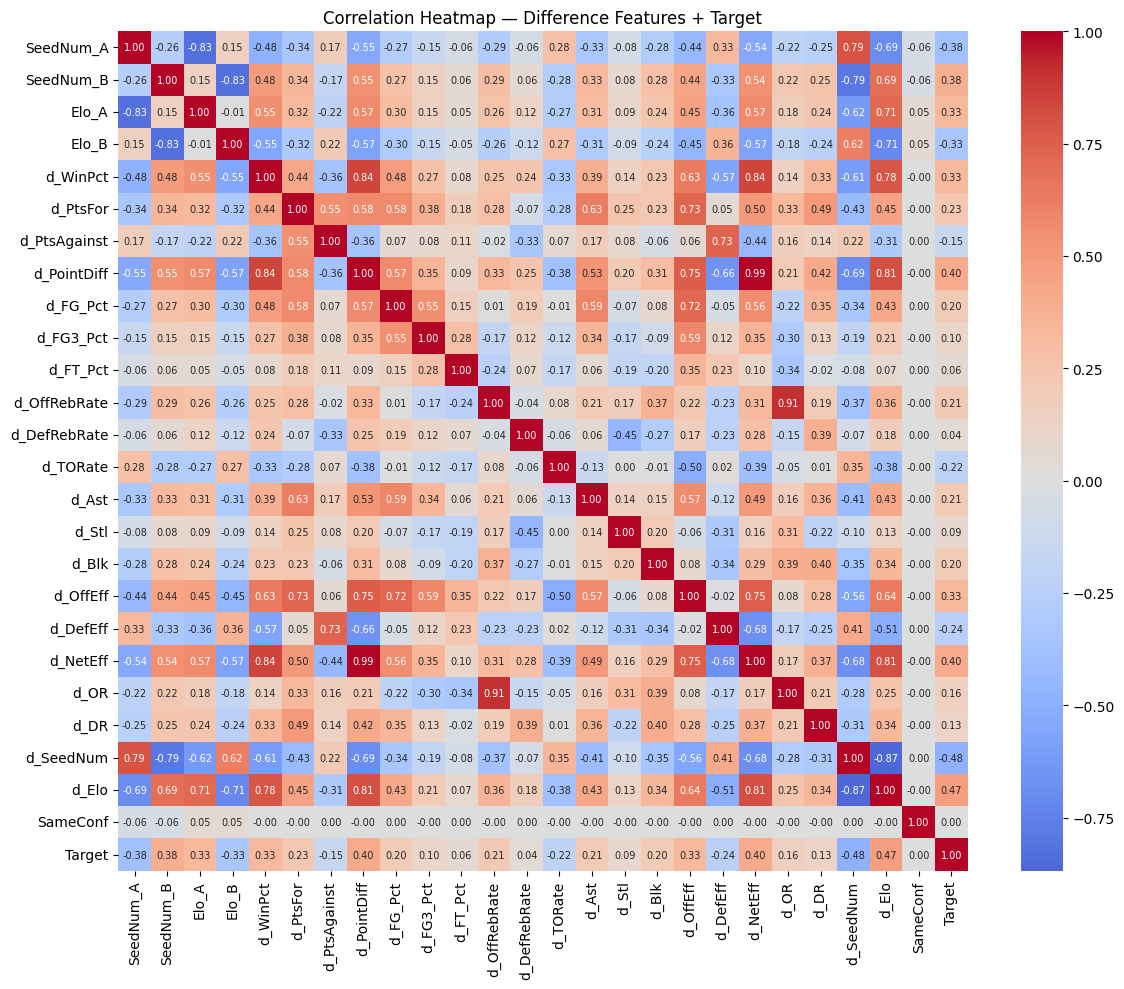


Top features correlated with Target:
Target         1.000000
d_SeedNum      0.482312
d_Elo          0.468923
d_PointDiff    0.404873
d_NetEff       0.403912
SeedNum_A      0.382439
SeedNum_B      0.382439
Elo_A          0.332810
Name: Target, dtype: float64


In [91]:
corr = matchups[FEATURE_COLS + ['Target']].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation Heatmap — Difference Features + Target')
plt.tight_layout()
plt.show()

target_corr = corr['Target'].abs().sort_values(ascending=False)
print('\nTop features correlated with Target:')
print(target_corr.head(8))

#### Select top features by correlation with Target

In [92]:
TOP_FEATURES = target_corr.index[1:9].tolist()  ##exclude Target itself
print('Selected features:', TOP_FEATURES)

Selected features: ['d_SeedNum', 'd_Elo', 'd_PointDiff', 'd_NetEff', 'SeedNum_A', 'SeedNum_B', 'Elo_A', 'Elo_B']


## 6. Train / Test Split

In [93]:
##Split by season to avoid data leakage
train_mask = matchups['Season'] < 2022
test_mask  = matchups['Season'] >= 2022

X_train_raw = matchups.loc[train_mask, TOP_FEATURES].values
X_test_raw  = matchups.loc[test_mask,  TOP_FEATURES].values
y_train = matchups.loc[train_mask, 'Target'].values
y_test = matchups.loc[test_mask,  'Target'].values

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

print(f'Train: {X_train.shape[0]:,} samples  |  Test: {X_test.shape[0]:,} samples')
print(f'Train seasons: {matchups.loc[train_mask,"Season"].min()} – {matchups.loc[train_mask,"Season"].max()}')
print(f'Test seasons:  {matchups.loc[test_mask,"Season"].min()} – {matchups.loc[test_mask,"Season"].max()}')

Train: 2,362 samples  |  Test: 536 samples
Train seasons: 2003 – 2021
Test seasons:  2022 – 2025


## 7. t-SNE Visualization

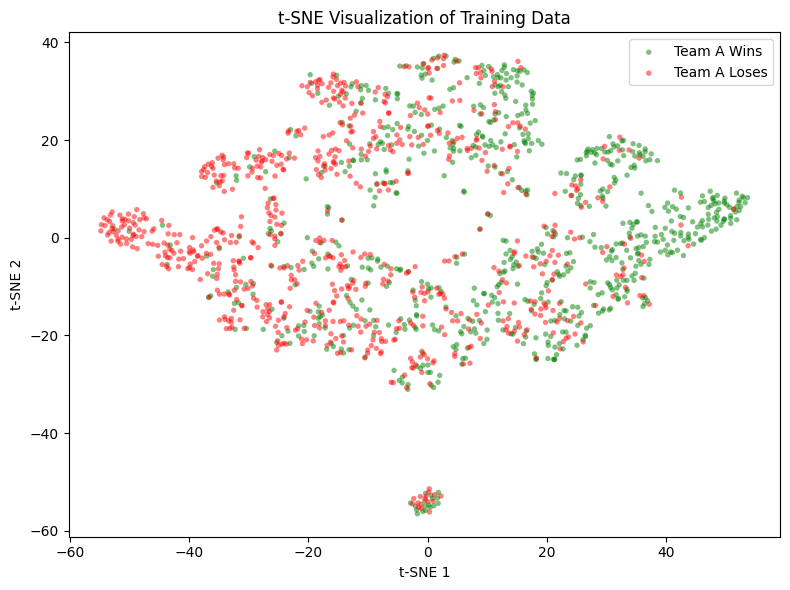

In [94]:
np.random.seed(RANDOM_STATE)
n_sample = min(1500, len(X_train))
idx = np.random.choice(len(X_train), n_sample, replace=False)

tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE)
X_2d = tsne.fit_transform(X_train[idx])

plt.figure(figsize=(8, 6))
for label, color, name in [(1, 'green', 'Team A Wins'), (0, 'red', 'Team A Loses')]:
    mask = y_train[idx] == label
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, label=name, alpha=0.5, s=15, edgecolors='none')
plt.title('t-SNE Visualization of Training Data')
plt.xlabel('t-SNE 1'); plt.ylabel('t-SNE 2')
plt.legend()
plt.tight_layout()
plt.show()

---
# Modeling

In [95]:
!pip install xgboost statsmodels -q
print("Done.")

Done.


In [96]:
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

import xgboost as xgb

from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

##TensorFlow is optional — gracefully skip if not installed
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
    TF_AVAILABLE = True
    tf.random.set_seed(42)
    print('TensorFlow:', tf.__version__)
except (ImportError, Exception):
    TF_AVAILABLE = False
    print('TensorFlow not found — Neural Network section will be skipped.')

import warnings
warnings.filterwarnings('ignore')
print('Modeling imports done.')

TensorFlow not found — Neural Network section will be skipped.
Modeling imports done.


## 8. Feature Sets & Scalers
We alias the EDA's top-feature train/test split and add a second scaler over all 25 features for ensemble and neural network models.



In [97]:
##EDA notebook already defines: matchups, FEATURE_COLS, TOP_FEATURES,
##train_mask, test_mask, X_train, X_test, scaler, y_train, y_test
##Alias the EDA's top-feature splits so modeling code is self-consistent
X_train_top = X_train
X_test_top = X_test
scaler_top = scaler
ALL_FEATURES = FEATURE_COLS  ##all 25 engineered features

##Add a scaler for all features (ensemble / neural network models)
scaler_all = StandardScaler()
X_train_all = scaler_all.fit_transform(matchups.loc[train_mask, ALL_FEATURES])
X_test_all = scaler_all.transform(matchups.loc[test_mask,  ALL_FEATURES])

print(f'Top features  : {len(TOP_FEATURES)} — {TOP_FEATURES}')
print(f'All features  : {len(ALL_FEATURES)}')
print(f'Train samples : {X_train_all.shape[0]:,}')
print(f'Test  samples : {X_test_all.shape[0]:,}')

Top features  : 8 — ['d_SeedNum', 'd_Elo', 'd_PointDiff', 'd_NetEff', 'SeedNum_A', 'SeedNum_B', 'Elo_A', 'Elo_B']
All features  : 25
Train samples : 2,362
Test  samples : 536


## 9. Clustering Analysis
We cluster teams by their regular-season profile to discover natural **team quality tiers** (e.g., elite programs, mid-majors, bottom-feeders). We then verify that the clusters correspond to meaningfully different win rates using ANOVA.



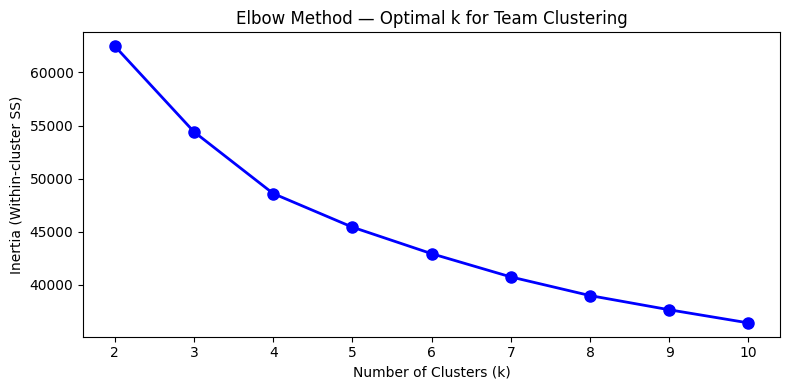

In [98]:
CLUSTER_FEATURES = ['WinPct','PointDiff','OffEff','DefEff','NetEff',
                    'FG_Pct','FG3_Pct','FT_Pct','TORate','OffRebRate','DefRebRate']

ts_cluster = team_stats.dropna(subset=CLUSTER_FEATURES).copy()
X_clust = StandardScaler().fit_transform(ts_cluster[CLUSTER_FEATURES])

##Elbow method
inertias = []
K_range  = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    inertias.append(km.fit(X_clust).inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster SS)')
plt.title('Elbow Method — Optimal k for Team Clustering')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

In [99]:
K_OPTIMAL = 5  ##elbow is at k=5 — five natural team tiers
kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=RANDOM_STATE, n_init=20)
ts_cluster['Cluster'] = kmeans.fit_predict(X_clust)

##Cluster profiles
profile = ts_cluster.groupby('Cluster')[CLUSTER_FEATURES + ['NumGames']].mean().round(3)
profile = profile.sort_values('WinPct', ascending=False)
print('\nCluster Profiles (sorted by Win Rate):')
print(profile[['WinPct','PointDiff','NetEff','FG_Pct','TORate']].to_string())

##Label clusters by tier
sorted_clusters = profile.index.tolist()
tier_names = {c: f'Tier {i+1} ({["Elite","Good","Average","Below-Avg","Weak"][i]})'
              for i, c in enumerate(sorted_clusters)}
ts_cluster['Tier'] = ts_cluster['Cluster'].map(tier_names)
print('\nCluster → Tier mapping:', tier_names)


Cluster Profiles (sorted by Win Rate):
         WinPct  PointDiff  NetEff  FG_Pct  TORate
Cluster                                           
4         0.752      9.309  13.773   0.465   0.157
1         0.567      2.200   3.229   0.451   0.150
2         0.532      1.051   1.567   0.436   0.178
3         0.348     -5.204  -7.593   0.427   0.163
0         0.256     -8.954 -13.186   0.406   0.192

Cluster → Tier mapping: {4: 'Tier 1 (Elite)', 1: 'Tier 2 (Good)', 2: 'Tier 3 (Average)', 3: 'Tier 4 (Below-Avg)', 0: 'Tier 5 (Weak)'}


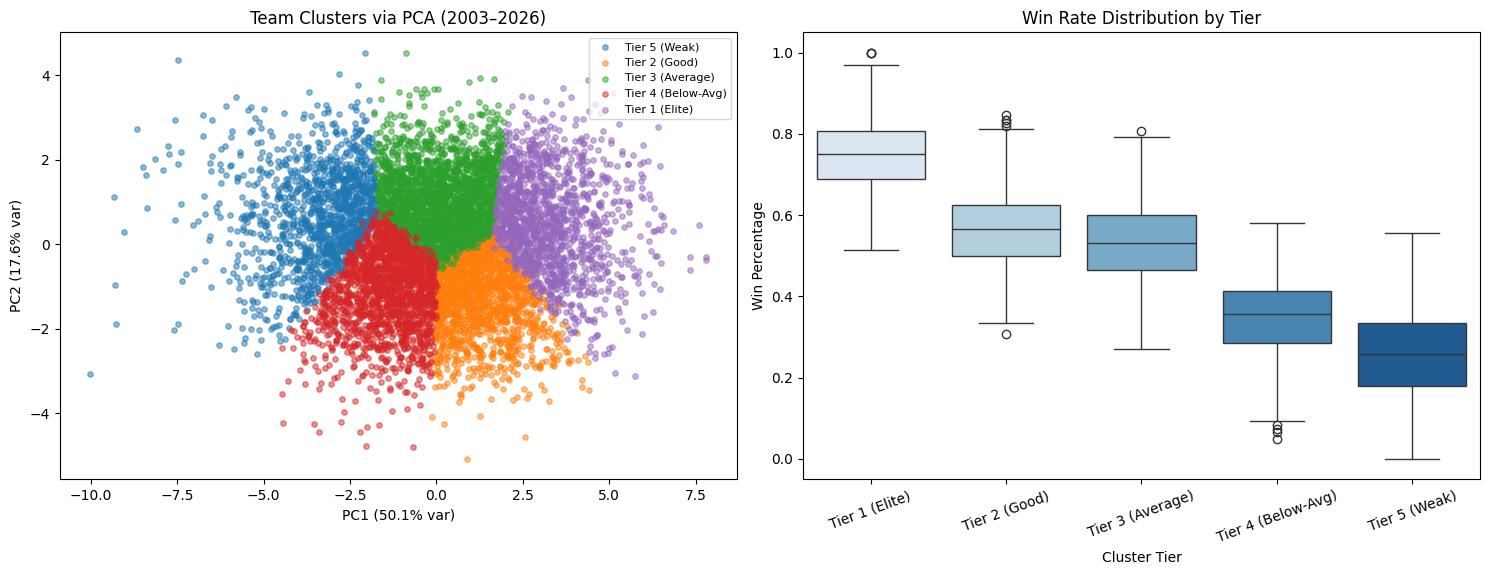

In [100]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca2.fit_transform(X_clust)
ts_cluster['PC1'] = X_pca[:, 0]
ts_cluster['PC2'] = X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

##PCA scatter by cluster
palette = sns.color_palette('tab10', K_OPTIMAL)
for c in range(K_OPTIMAL):
    mask = ts_cluster['Cluster'] == c
    axes[0].scatter(ts_cluster.loc[mask,'PC1'], ts_cluster.loc[mask,'PC2'],
                    label=tier_names[c], alpha=0.5, s=15, color=palette[c])
axes[0].set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].set_title('Team Clusters via PCA (2003–2026)')
axes[0].legend(fontsize=8, loc='upper right')

##Win rate boxplot by tier — use seaborn which supports order
tier_order = [tier_names[c] for c in sorted_clusters]
sns.boxplot(data=ts_cluster, x='Tier', y='WinPct', order=tier_order,
            ax=axes[1], palette='Blues')
axes[1].set_title('Win Rate Distribution by Tier')
axes[1].set_xlabel('Cluster Tier')
axes[1].set_ylabel('Win Percentage')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('')
plt.tight_layout()
plt.show()

In [101]:
##ANOVA: Is mean win rate significantly different across clusters?
cluster_win_rates = [ts_cluster.loc[ts_cluster['Cluster']==c, 'WinPct'].values
                     for c in sorted_clusters]
f_stat_cl, p_val_cl = f_oneway(*cluster_win_rates)

print('=== One-Way ANOVA: Win Rate by Cluster ===')
print(f'F-statistic: {f_stat_cl:.2f}')
print(f'p-value: {p_val_cl:.2e}')
print(f'Result: {"Significant — clusters represent different quality tiers (p < 0.05)" if p_val_cl < 0.05 else "Not significant"}')

##Tukey HSD post-hoc for cluster ANOVA
win_flat = np.concatenate(cluster_win_rates)
labels_flat = np.concatenate([[tier_names[c]]*len(g) for c, g in zip(sorted_clusters, cluster_win_rates)])
tukey_cl = pairwise_tukeyhsd(win_flat, labels_flat, alpha=0.05)
print('\n=== Tukey HSD Post-Hoc (Cluster Win Rate) ===')
print(tukey_cl.summary())

=== One-Way ANOVA: Win Rate by Cluster ===
F-statistic: 6341.27
p-value: 0.00e+00
Result: Significant — clusters represent different quality tiers (p < 0.05)

=== Tukey HSD Post-Hoc (Cluster Win Rate) ===
            Multiple Comparison of Means - Tukey HSD, FWER=0.05            
      group1             group2       meandiff p-adj  lower   upper  reject
---------------------------------------------------------------------------
    Tier 1 (Elite)      Tier 2 (Good)  -0.1846   0.0 -0.1937 -0.1754   True
    Tier 1 (Elite)   Tier 3 (Average)  -0.2197   0.0 -0.2283  -0.211   True
    Tier 1 (Elite) Tier 4 (Below-Avg)   -0.404   0.0 -0.4131  -0.395   True
    Tier 1 (Elite)      Tier 5 (Weak)  -0.4962   0.0 -0.5059 -0.4865   True
     Tier 2 (Good)   Tier 3 (Average)  -0.0351   0.0 -0.0433 -0.0269   True
     Tier 2 (Good) Tier 4 (Below-Avg)  -0.2195   0.0 -0.2282 -0.2108   True
     Tier 2 (Good)      Tier 5 (Weak)  -0.3117   0.0  -0.321 -0.3023   True
  Tier 3 (Average) Tier 4 (Below-Av

## 10. Baseline Models
- **Naive:** always predict 0.5 (maximum-entropy baseline)
- **Seed-only Logistic Regression:** uses only tournament seed difference
- **Full Logistic Regression:** top 8 correlated features



In [102]:
results = {}

##Naive 0.5
y_prob_naive = np.full(len(y_test), 0.5)
results['Naive (0.5)'] = {
    'log_loss': log_loss(y_test, y_prob_naive),
    'accuracy': accuracy_score(y_test, (y_prob_naive >= 0.5).astype(int)),
    'roc_auc': 0.5,
    'probs': y_prob_naive
}

##Seed-Only Logistic Regression
seed_feat = ['d_SeedNum']
scaler_seed = StandardScaler()
X_tr_seed = scaler_seed.fit_transform(matchups.loc[train_mask, seed_feat])
X_te_seed = scaler_seed.transform(matchups.loc[test_mask, seed_feat])
lr_seed = LogisticRegression(max_iter=500, random_state=RANDOM_STATE)
lr_seed.fit(X_tr_seed, y_train)
y_prob_seed = lr_seed.predict_proba(X_te_seed)[:, 1]
results['Seed-Only LR'] = {
    'log_loss': log_loss(y_test, y_prob_seed),
    'accuracy': accuracy_score(y_test, (y_prob_seed >= 0.5).astype(int)),
    'roc_auc': roc_auc_score(y_test, y_prob_seed),
    'probs': y_prob_seed
}

##Logistic Regression (top features)
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_top, y_train)
y_prob_lr = lr.predict_proba(X_test_top)[:, 1]
results['Logistic Regression'] = {
    'log_loss': log_loss(y_test, y_prob_lr),
    'accuracy': accuracy_score(y_test, (y_prob_lr >= 0.5).astype(int)),
    'roc_auc': roc_auc_score(y_test, y_prob_lr),
    'probs': y_prob_lr
}

for name, m in results.items():
    print(f'{name:25s}  Log Loss={m["log_loss"]:.4f}  Acc={m["accuracy"]:.4f}  AUC={m["roc_auc"]:.4f}')

# Train vs test log loss — check for overfitting
y_prob_lr_train = lr.predict_proba(X_train_top)[:, 1]
print(f'\nLogistic Regression — Train Log Loss: {log_loss(y_train, y_prob_lr_train):.4f}  Test Log Loss: {results["Logistic Regression"]["log_loss"]:.4f}')


Naive (0.5)                Log Loss=0.6931  Acc=0.5000  AUC=0.5000
Seed-Only LR               Log Loss=0.5723  Acc=0.7015  AUC=0.7715
Logistic Regression        Log Loss=0.5732  Acc=0.7127  AUC=0.7732

Logistic Regression — Train Log Loss: 0.5474  Test Log Loss: 0.5732


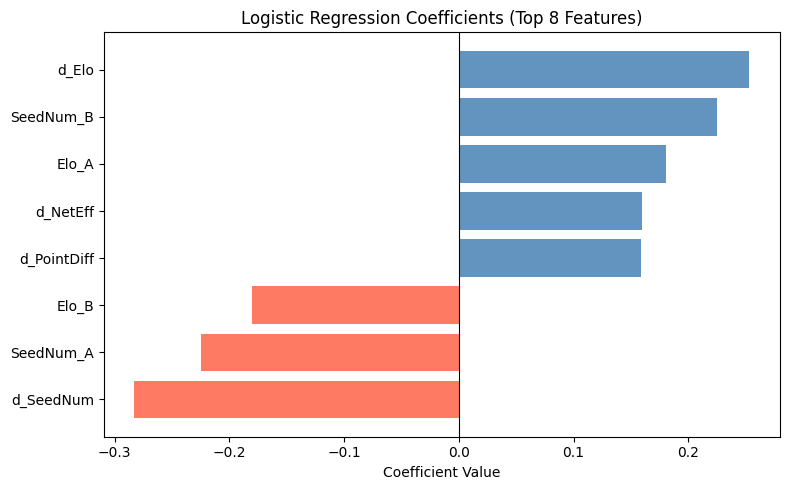

In [103]:
##Logistic Regression coefficient plot
coef_df = pd.DataFrame({'Feature': TOP_FEATURES, 'Coefficient': lr.coef_[0]})
coef_df = coef_df.sort_values('Coefficient')

plt.figure(figsize=(8, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.85)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Logistic Regression Coefficients (Top 8 Features)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 11. Ensemble Models
Random Forest and XGBoost both capture nonlinear feature interactions and are robust to multicollinearity.
Both use all 25 engineered features.



In [104]:
##Random Forest
rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_all, y_train)
y_prob_rf = rf.predict_proba(X_test_all)[:, 1]
results['Random Forest'] = {
    'log_loss': log_loss(y_test, y_prob_rf),
    'accuracy': accuracy_score(y_test, (y_prob_rf >= 0.5).astype(int)),
    'roc_auc': roc_auc_score(y_test, y_prob_rf),
    'probs': y_prob_rf
}
print(f'Random Forest   Log Loss={results["Random Forest"]["log_loss"]:.4f}  '
      f'Acc={results["Random Forest"]["accuracy"]:.4f}  '
      f'AUC={results["Random Forest"]["roc_auc"]:.4f}')

Random Forest   Log Loss=0.5833  Acc=0.6959  AUC=0.7668


In [105]:
##XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    use_label_encoder=False,
    eval_metric='logloss',
    early_stopping_rounds=30,
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_model.fit(
    X_train_all, y_train,
    eval_set=[(X_test_all, y_test)],
    verbose=False
)
y_prob_xgb = xgb_model.predict_proba(X_test_all)[:, 1]
results['XGBoost'] = {
    'log_loss': log_loss(y_test, y_prob_xgb),
    'accuracy': accuracy_score(y_test, (y_prob_xgb >= 0.5).astype(int)),
    'roc_auc': roc_auc_score(y_test, y_prob_xgb),
    'probs': y_prob_xgb
}
print(f'XGBoost         Log Loss={results["XGBoost"]["log_loss"]:.4f}  '
      f'Acc={results["XGBoost"]["accuracy"]:.4f}  '
      f'AUC={results["XGBoost"]["roc_auc"]:.4f}')

XGBoost         Log Loss=0.5783  Acc=0.6978  AUC=0.7689


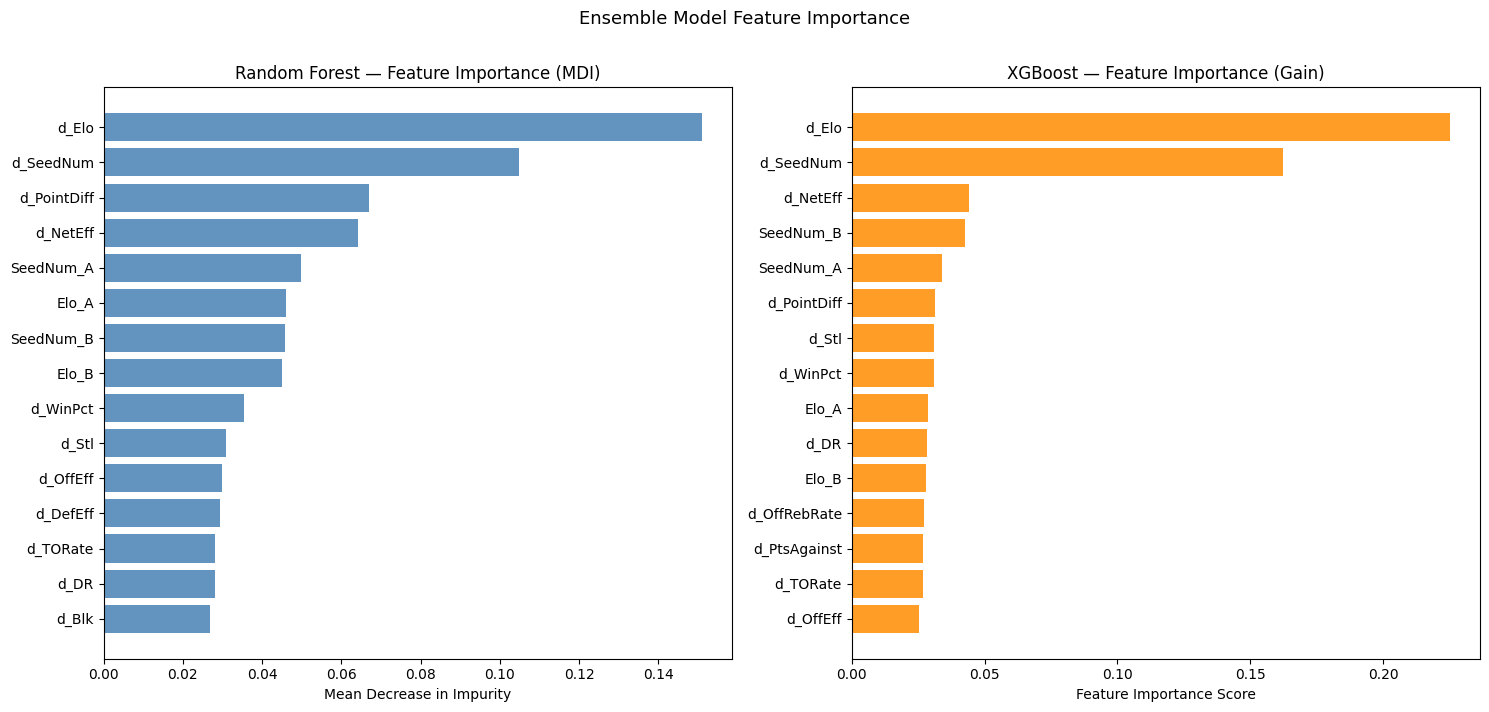

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

N_SHOW = 15

##RF importance
rf_imp = pd.DataFrame({'Feature': ALL_FEATURES, 'Importance': rf.feature_importances_}).sort_values('Importance')
axes[0].barh(rf_imp['Feature'].tail(N_SHOW), rf_imp['Importance'].tail(N_SHOW), color='steelblue', alpha=0.85)
axes[0].set_title('Random Forest — Feature Importance (MDI)')
axes[0].set_xlabel('Mean Decrease in Impurity')

##XGBoost importance
xgb_imp = pd.DataFrame({'Feature': ALL_FEATURES, 'Importance': xgb_model.feature_importances_}).sort_values('Importance')
axes[1].barh(xgb_imp['Feature'].tail(N_SHOW), xgb_imp['Importance'].tail(N_SHOW), color='darkorange', alpha=0.85)
axes[1].set_title('XGBoost — Feature Importance (Gain)')
axes[1].set_xlabel('Feature Importance Score')

plt.suptitle('Ensemble Model Feature Importance', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 12. Neural Network Model (MLP)
A 3-hidden-layer feed-forward network with BatchNorm and Dropout.
Uses all 25 features; trained with Adam and early stopping.



In [107]:
if not TF_AVAILABLE:
    print('TensorFlow not available — skipping. Install with: pip install tensorflow')
else:
    def build_mlp(input_dim, dropout=0.35):
        model = keras.Sequential([
            layers.Input(shape=(input_dim,)),
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(dropout),
            layers.Dense(64, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(dropout),
            layers.Dense(32, activation='relu'),
            layers.Dropout(dropout / 2),
            layers.Dense(1, activation='sigmoid')
        ])
        model.compile(
            optimizer=keras.optimizers.Adam(learning_rate=0.001),
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
        return model

    nn_model = build_mlp(len(ALL_FEATURES))
    nn_model.summary()

TensorFlow not available — skipping. Install with: pip install tensorflow


In [108]:
if not TF_AVAILABLE:
    print('TensorFlow not available — skipping neural network training.')
else:
    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=0)
    reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=8, min_lr=1e-5, verbose=0)

    history = nn_model.fit(
        X_train_all, y_train,
        epochs=200,
        batch_size=64,
        validation_split=0.15,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    print(f'Training stopped at epoch {len(history.history["loss"])}')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history.history['loss'],     label='Train', color='steelblue')
    axes[0].plot(history.history['val_loss'], label='Val',   color='tomato')
    axes[0].set_title('Loss (Binary Cross-Entropy)')
    axes[0].set_xlabel('Epoch'); axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='Train', color='steelblue')
    axes[1].plot(history.history['val_accuracy'], label='Val',   color='tomato')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch'); axes[1].legend()

    plt.suptitle('Neural Network Training Curves', fontsize=13)
    plt.tight_layout()
    plt.show()

    y_prob_nn = nn_model.predict(X_test_all, verbose=0).ravel()
    results['Neural Network (MLP)'] = {
        'log_loss': log_loss(y_test, y_prob_nn),
        'accuracy': accuracy_score(y_test, (y_prob_nn >= 0.5).astype(int)),
        'roc_auc':  roc_auc_score(y_test, y_prob_nn),
        'probs':    y_prob_nn
    }
    print(f'Neural Network  Log Loss={results["Neural Network (MLP)"]["log_loss"]:.4f}  '
          f'Acc={results["Neural Network (MLP)"]["accuracy"]:.4f}  '
          f'AUC={results["Neural Network (MLP)"]["roc_auc"]:.4f}')

TensorFlow not available — skipping neural network training.


## 13. Other Models
- **Support Vector Machine (RBF kernel):** finds a nonlinear decision boundary in feature space
- **k-Nearest Neighbors:** predicts based on the k most similar historical matchups
- **Gemini 2.5 Flash (LLM):** prompted with matchup statistics and uses zero-shot reasoning to predict the winner



In [109]:
##SVM with RBF kernel
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_top, y_train)
y_prob_svm = svm.predict_proba(X_test_top)[:, 1]
results['SVM (RBF)'] = {
    'log_loss': log_loss(y_test, y_prob_svm),
    'accuracy': accuracy_score(y_test, (y_prob_svm >= 0.5).astype(int)),
    'roc_auc': roc_auc_score(y_test, y_prob_svm),
    'probs': y_prob_svm
}

##k-Nearest Neighbors
##Grid search over k
knn_scores = []
K_vals = [5, 11, 21, 31, 51, 71]
for k in K_vals:
    knn_k = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    knn_k.fit(X_train_top, y_train)
    knn_scores.append(log_loss(y_test, knn_k.predict_proba(X_test_top)[:, 1]))

best_k = K_vals[np.argmin(knn_scores)]
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean', weights='distance')
knn.fit(X_train_top, y_train)
y_prob_knn = knn.predict_proba(X_test_top)[:, 1]
results['k-NN'] = {
    'log_loss': log_loss(y_test, y_prob_knn),
    'accuracy': accuracy_score(y_test, (y_prob_knn >= 0.5).astype(int)),
    'roc_auc': roc_auc_score(y_test, y_prob_knn),
    'probs': y_prob_knn
}

print(f'SVM (RBF)       Log Loss={results["SVM (RBF)"]["log_loss"]:.4f}  '
      f'Acc={results["SVM (RBF)"]["accuracy"]:.4f}  AUC={results["SVM (RBF)"]["roc_auc"]:.4f}')
print(f'k-NN (k={best_k:2d})    Log Loss={results["k-NN"]["log_loss"]:.4f}  '
      f'Acc={results["k-NN"]["accuracy"]:.4f}  AUC={results["k-NN"]["roc_auc"]:.4f}')

SVM (RBF)       Log Loss=0.5833  Acc=0.7071  AUC=0.7662
k-NN (k=71)    Log Loss=0.5832  Acc=0.7090  AUC=0.7668


In [110]:
##Gemini LLM integration
%pip install --upgrade --quiet google-genai gitingest
import sys

# Additional authentication is required for Google Colab
if "google.colab" in sys.modules:
    # Authenticate user to Google Cloud
    from google.colab import auth

    auth.authenticate_user()
import os

from google import genai

# fmt: off
PROJECT_ID = "dsci303-test"  # @param {type: "string", placeholder: "[your-project-id]", isTemplate: true}

# fmt: on
if not PROJECT_ID or PROJECT_ID == "[your-project-id]":
    PROJECT_ID = str(os.environ.get("GOOGLE_CLOUD_PROJECT"))

LOCATION = os.environ.get("GOOGLE_CLOUD_REGION", "global")

client = genai.Client(vertexai=True, project=PROJECT_ID, location=LOCATION)
import nest_asyncio
from IPython.display import Audio, Image, Markdown, Video, display
from gitingest import ingest
from google.genai.types import CreateCachedContentConfig, GenerateContentConfig, Part

nest_asyncio.apply()
MODEL_ID = "gemini-2.5-flash"  # @param {type: "string"}
question = "What is the average weather in Houston, TX in the middle of April?"
prompt = """
Considering the weather, please provide some outfit suggestions.

Give examples for the daytime and the evening.
"""

contents = [question, prompt]
response = client.models.generate_content(model=MODEL_ID, contents=contents)
display(Markdown(response.text))

Note: you may need to restart the kernel to use updated packages.


2026-04-18 16:22:31.862 | INFO     | logging:callHandlers:1706 | AFC is enabled with max remote calls: 10.
Compute Engine Metadata server unavailable on attempt 1 of 3. Reason: HTTPConnectionPool(host='169.254.169.254', port=80): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='169.254.169.254', port=80) at 0x2ac572010>, 'Connection to 169.254.169.254 timed out. (connect timeout=3)'))
Compute Engine Metadata server unavailable on attempt 2 of 3. Reason: HTTPConnectionPool(host='169.254.169.254', port=80): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='169.254.169.254', port=80) at 0x2a0a85d90>, 'Connection to 169.254.169.254 timed out. (connect timeout=3)'))
Compute Engine Metadata server unavailable on attempt 3 of 3. Reason: HTTPConnectionPool(host='169.254.169.254', port=80): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='169.254.169.254', port=80) at 0x2a0a85210>, 'Con

DefaultCredentialsError: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.

2026-04-18 16:22:44.394 | INFO     | logging:callHandlers:1706 | Exception in execute request:
---------------------------------------------------------------------------
DefaultCredentialsError                   Traceback (most recent call last)
Cell In[110], line 40
     33 prompt = """
     34 Considering the weather, please provide some outfit suggestions.
     35 
     36 Give examples for the daytime and the evening.
     37 """
     39 contents = [question, prompt]
---> 40 response = client.models.generate_content(model=MODEL_ID, contents=contents)
     41 display(Markdown(response.text))

File ~/anaconda3/envs/mm2026/lib/python3.11/site-packages/google/genai/models.py:6276, in Models.generate_content(self, model, contents, config)
   6274 while remaining_remote_calls_afc > 0:
   6275   i += 1
-> 6276   response = self._generate_content(
   6277       model=model, contents=contents, config=parsed_config
   6278   )
   6280   function_map = _extra_utils.get_function_map(parsed_co

In [ ]:
import time

# Sample 50 games from the test set (one ordering per game to avoid duplicates)
test_df = matchups.loc[test_mask].reset_index(drop=True)
test_df = test_df[test_df["TeamA"] < test_df["TeamB"]]
np.random.seed(RANDOM_STATE)
sample = test_df.sample(n=50, random_state=RANDOM_STATE).reset_index(drop=True)

DISPLAY_FEATURES = [
    "d_SeedNum", "d_Elo", "d_WinPct", "d_PointDiff",
    "d_NetEff", "d_FG_Pct", "d_TORate", "d_OffRebRate"
]

gemini_preds = []
gemini_reasons = []

for _, row in sample.iterrows():
    sample_df = pd.DataFrame([row[DISPLAY_FEATURES].values], columns=DISPLAY_FEATURES)

    prompt = f"""
You are an NCAA basketball analyst. Given the following matchup statistics
(all values are Team A minus Team B, so positive = Team A is better):

{sample_df.to_string(index=False)}

Feature key:
- d_SeedNum: seed difference (positive = Team A has a worse/higher seed number)
- d_Elo: Elo rating difference
- d_WinPct: win percentage difference
- d_PointDiff: average point differential difference
- d_NetEff: net efficiency difference
- d_FG_Pct: field goal percentage difference
- d_TORate: turnover rate difference
- d_OffRebRate: offensive rebound rate difference

Possible outcomes:
1 = Team A wins
0 = Team B wins

First, on the first line, output ONLY the predicted outcome number (0 or 1).
Then, on the following lines, explain why you predict that way.
"""

    response = client.models.generate_content(
        model=MODEL_ID,
        contents=prompt,
    )

    full_text = response.text.strip()
    lines = full_text.splitlines()

    raw_pred = lines[0].strip() if lines else ""
    try:
        pred = int(raw_pred)
    except:
        pred = None

    reasoning = "\n".join(lines[1:]).strip() if len(lines) > 1 else ""

    gemini_preds.append(pred)
    gemini_reasons.append(reasoning)

    time.sleep(0.5)  # gentle rate limiting

results_gemini = pd.DataFrame({
    "sample_index": range(len(sample)),
    "gemini_pred": gemini_preds,
    "true_label": sample["Target"].values,
    "reasoning": gemini_reasons
})

results_gemini

In [ ]:
def clean_pred(p):
    if p is None:
        return None
    try:
        v = int(str(p).strip())
        return v if v in (0, 1) else None
    except:
        return None

results_gemini['clean_pred'] = results_gemini['gemini_pred'].apply(clean_pred)
results_gemini['correct']    = results_gemini['clean_pred'] == results_gemini['true_label']

valid    = results_gemini['clean_pred'].notnull()
accuracy = results_gemini.loc[valid, 'correct'].mean()

print('=== Gemini 2.5 Flash — Standalone Evaluation ===')
print(f'Sample size : {valid.sum()} games (2022–2025 test set)')
print(f'Accuracy    : {accuracy:.4f}')
print(f'Note: Gemini outputs class labels (0/1), not calibrated probabilities.')
print(f'      It is excluded from the log-loss model comparison in Section 14.')

mistakes = results_gemini[~results_gemini['correct'] & valid]
print(f'\nMispredictions: {len(mistakes)} / {valid.sum()}')
print(mistakes[['sample_index','clean_pred','true_label']].to_string(index=False))


## 14. Test-Set Model Comparison



=== Test Set Results (2022–2025) ===
                 Model  Log Loss  Accuracy  ROC-AUC
1         Seed-Only LR    0.5723    0.7015   0.7715
2  Logistic Regression    0.5732    0.7127   0.7732
3              XGBoost    0.5783    0.6978   0.7689
4                 k-NN    0.5832    0.7090   0.7668
5            SVM (RBF)    0.5833    0.7071   0.7662
6        Random Forest    0.5833    0.6959   0.7668
7          Naive (0.5)    0.6931    0.5000   0.5000


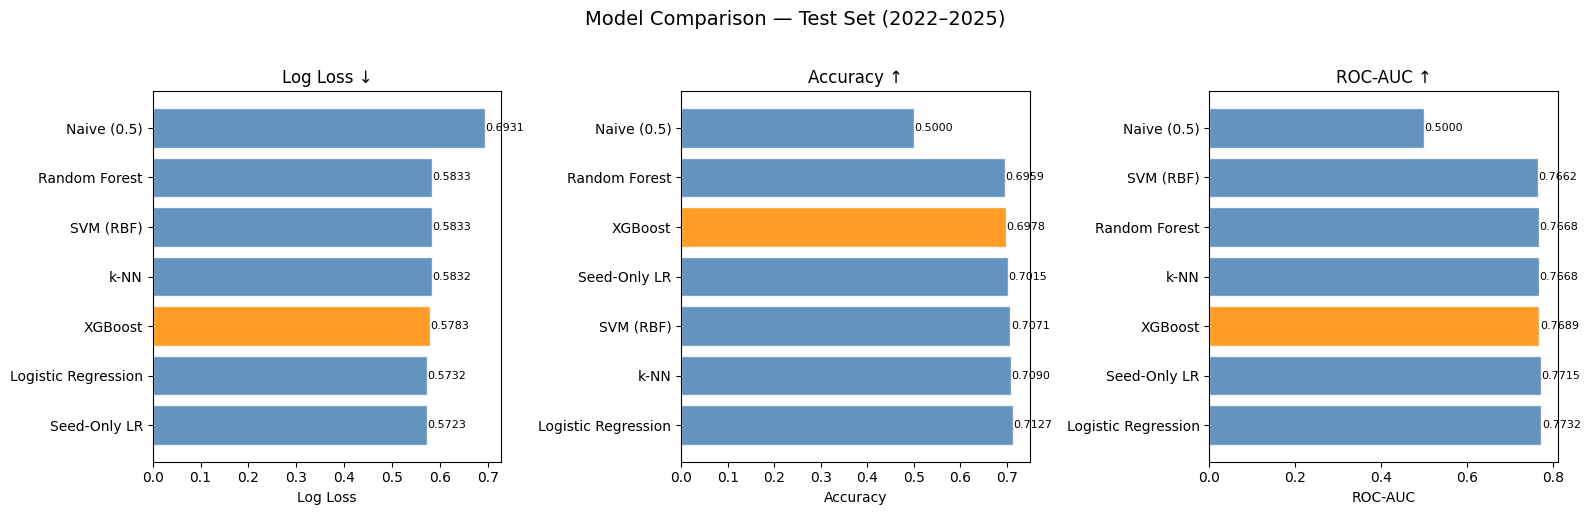

In [111]:
compare_models = list(results.keys())
summary = pd.DataFrame({
    'Model': compare_models,
    'Log Loss': [results[m]['log_loss'] for m in compare_models],
    'Accuracy': [results[m]['accuracy'] for m in compare_models],
    'ROC-AUC':  [results[m]['roc_auc']  for m in compare_models],
}).sort_values('Log Loss').reset_index(drop=True)
summary.index += 1
print('=== Test Set Results (2022–2025) ===')
print(summary.to_string(float_format='%.4f'))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.9, len(compare_models)))

for ax, metric, ascending, label in [
    (axes[0], 'Log Loss', True,  'Log Loss ↓'),
    (axes[1], 'Accuracy', False, 'Accuracy ↑'),
    (axes[2], 'ROC-AUC',  False, 'ROC-AUC ↑'),
]:
    s = summary.sort_values(metric, ascending=ascending)
    bars = ax.barh(s['Model'], s[metric],
                   color=['steelblue' if m != 'XGBoost' else 'darkorange' for m in s['Model']],
                   alpha=0.85, edgecolor='white')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel(metric)
    for bar, val in zip(bars, s[metric]):
        ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)

plt.suptitle('Model Comparison — Test Set (2022–2025)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 15. Cross-Validation & Statistical Analysis

### Temporal Cross-Validation
To rigorously compare models, we use **leave-one-season-out** CV over 12 seasons (2010–2021): for each fold, we train on all seasons *before* the held-out season, then evaluate on that season. This respects temporal ordering and avoids future data leakage.

### Statistical Tests
1. **One-Way ANOVA** — tests whether any model has a significantly different mean log-loss
2. **Tukey HSD post-hoc** — pairwise comparisons with family-wise error control



In [112]:
CV_SEASONS = list(range(2010, 2022))  ##12 holdout seasons

CV_MODELS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=10,
                                                   min_samples_leaf=5, random_state=RANDOM_STATE, n_jobs=-1),
    'XGBoost':             xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                                              subsample=0.8, colsample_bytree=0.8,
                                              use_label_encoder=False, eval_metric='logloss',
                                              random_state=RANDOM_STATE, verbosity=0),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=RANDOM_STATE),
    'k-NN':                KNeighborsClassifier(n_neighbors=21, metric='euclidean', weights='distance'),
}

FEAT_MAP = {
    'Logistic Regression': TOP_FEATURES,
    'Random Forest':       ALL_FEATURES,
    'XGBoost':             ALL_FEATURES,
    'SVM (RBF)':           TOP_FEATURES,
    'k-NN':                TOP_FEATURES,
}

cv_scores = {name: [] for name in CV_MODELS}
completed_seasons = []  ##track which seasons actually ran

for test_season in CV_SEASONS:
    tr_mask = matchups['Season'] < test_season
    te_mask = matchups['Season'] == test_season
    y_tr = matchups.loc[tr_mask, 'Target'].values
    y_te = matchups.loc[te_mask, 'Target'].values

    if len(y_te) == 0 or len(np.unique(y_tr)) < 2:
        continue

    completed_seasons.append(test_season)
    for name, model in CV_MODELS.items():
        feats = FEAT_MAP[name]
        X_tr_raw = matchups.loc[tr_mask, feats].values
        X_te_raw = matchups.loc[te_mask, feats].values
        sc = StandardScaler()
        X_tr_s = sc.fit_transform(X_tr_raw)
        X_te_s = sc.transform(X_te_raw)
        model.fit(X_tr_s, y_tr)
        y_prob_cv = model.predict_proba(X_te_s)[:, 1]
        cv_scores[name].append(log_loss(y_te, y_prob_cv))

print(f'CV complete — {len(completed_seasons)} folds per model: {completed_seasons}')
cv_df = pd.DataFrame(cv_scores, index=completed_seasons)
print('\nCV Log-Loss by season:')
print(cv_df.round(4).to_string())
print('\nMean ± Std:')
print(cv_df.agg(['mean','std']).round(4).to_string())

CV complete — 11 folds per model: [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021]

CV Log-Loss by season:
      Logistic Regression  Random Forest  XGBoost  SVM (RBF)    k-NN
2010               0.5497         0.5359   0.5892     0.5949  1.0629
2011               0.6395         0.6562   0.7619     0.6800  0.6686
2012               0.5785         0.5716   0.6366     0.5635  1.5524
2013               0.6173         0.5986   0.7129     0.6344  0.6486
2014               0.6096         0.6184   0.6800     0.6452  0.6295
2015               0.5066         0.5231   0.5485     0.5159  1.0366
2016               0.5526         0.5581   0.5699     0.5604  1.0897
2017               0.5272         0.5170   0.5627     0.5401  0.5527
2018               0.6151         0.5824   0.6009     0.5929  1.0864
2019               0.5026         0.5026   0.4790     0.5742  0.5250
2021               0.6364         0.5992   0.6203     0.6755  0.6263

Mean ± Std:
      Logistic Regression  Random 

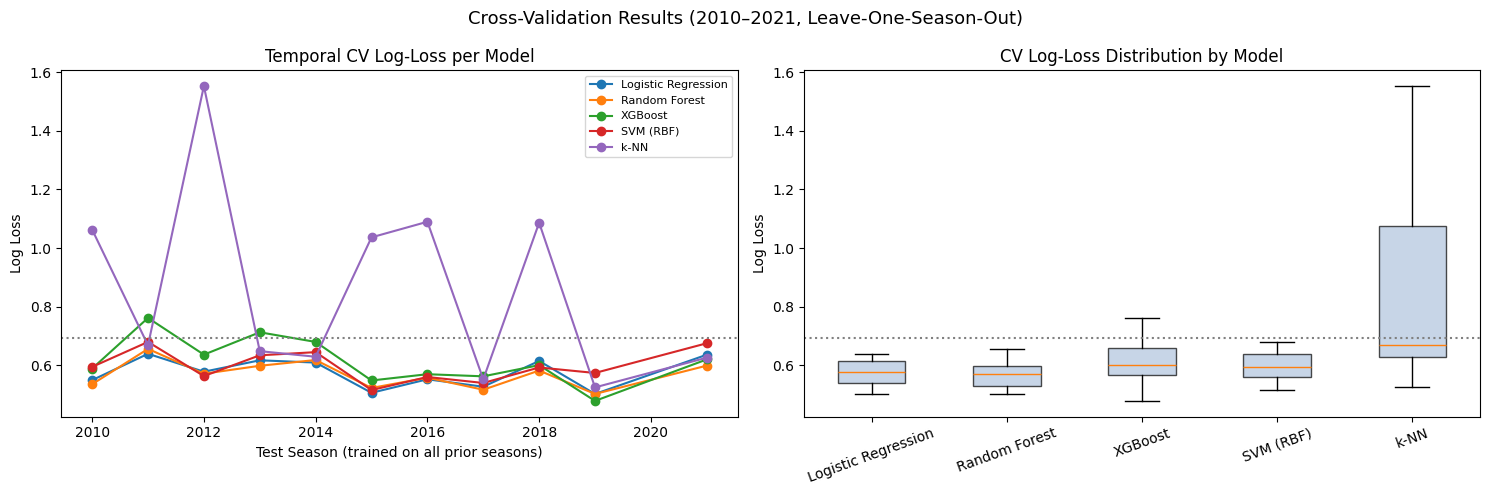

In [113]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

##Line plot: CV log-loss over time
for name in cv_scores:
    axes[0].plot(completed_seasons, cv_scores[name], marker='o', label=name)
axes[0].set_xlabel('Test Season (trained on all prior seasons)')
axes[0].set_ylabel('Log Loss')
axes[0].set_title('Temporal CV Log-Loss per Model')
axes[0].legend(fontsize=8)
axes[0].axhline(0.693, color='gray', linestyle=':', label='Naive 0.5 baseline')

##Boxplot: distribution of CV scores per model
axes[1].boxplot([cv_scores[n] for n in cv_scores], labels=list(cv_scores.keys()),
                patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
axes[1].set_ylabel('Log Loss')
axes[1].set_title('CV Log-Loss Distribution by Model')
axes[1].tick_params(axis='x', rotation=20)
axes[1].axhline(0.693, color='gray', linestyle=':', label='Naive baseline')

plt.suptitle(f'Cross-Validation Results ({completed_seasons[0]}–{completed_seasons[-1]}, Leave-One-Season-Out)', fontsize=13)
plt.tight_layout()
plt.show()

In [114]:
##One-Way ANOVA: Do models differ significantly in CV log-loss?

groups = [cv_scores[n] for n in cv_scores]
f_stat_models, p_val_models = f_oneway(*groups)

print('=== One-Way ANOVA: CV Log-Loss by Model ===')
print(f'F-statistic : {f_stat_models:.4f}')
print(f'p-value     : {p_val_models:.4f}')
if p_val_models < 0.05:
    print('Result      : Significant (p < 0.05) — at least one model differs from the rest.')
else:
    print('Result      : Not significant (p ≥ 0.05) — differences may be due to chance.')

##Descriptive stats per model
print('\nDescriptive statistics (CV Log-Loss):')
for name in cv_scores:
    s = cv_scores[name]
    print(f'  {name:25s}  mean={np.mean(s):.4f}  std={np.std(s):.4f}  min={np.min(s):.4f}  max={np.max(s):.4f}')

=== One-Way ANOVA: CV Log-Loss by Model ===
F-statistic : 6.9775
p-value     : 0.0002
Result      : Significant (p < 0.05) — at least one model differs from the rest.

Descriptive statistics (CV Log-Loss):
  Logistic Regression        mean=0.5759  std=0.0485  min=0.5026  max=0.6395
  Random Forest              mean=0.5694  std=0.0452  min=0.5026  max=0.6562
  XGBoost                    mean=0.6147  std=0.0765  min=0.4790  max=0.7619
  SVM (RBF)                  mean=0.5979  std=0.0519  min=0.5159  max=0.6800
  k-NN                       mean=0.8617  std=0.3092  min=0.5250  max=1.5524


=== Tukey HSD Post-Hoc Test (CV Log-Loss) ===
          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
       group1           group2    meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
Logistic Regression Random Forest  -0.0065    1.0  -0.193 0.1799  False
Logistic Regression     SVM (RBF)    0.022 0.9972 -0.1645 0.2084  False
Logistic Regression       XGBoost   0.0388 0.9761 -0.1476 0.2253  False
Logistic Regression          k-NN   0.2858 0.0006  0.0993 0.4722   True
      Random Forest     SVM (RBF)   0.0285 0.9925 -0.1579  0.215  False
      Random Forest       XGBoost   0.0454 0.9581 -0.1411 0.2318  False
      Random Forest          k-NN   0.2923 0.0005  0.1059 0.4788   True
          SVM (RBF)       XGBoost   0.0168  0.999 -0.1696 0.2033  False
          SVM (RBF)          k-NN   0.2638 0.0019  0.0773 0.4502   True
            XGBoost          k-NN    0.247  0.004  0.0605 0.4334   True
------------------

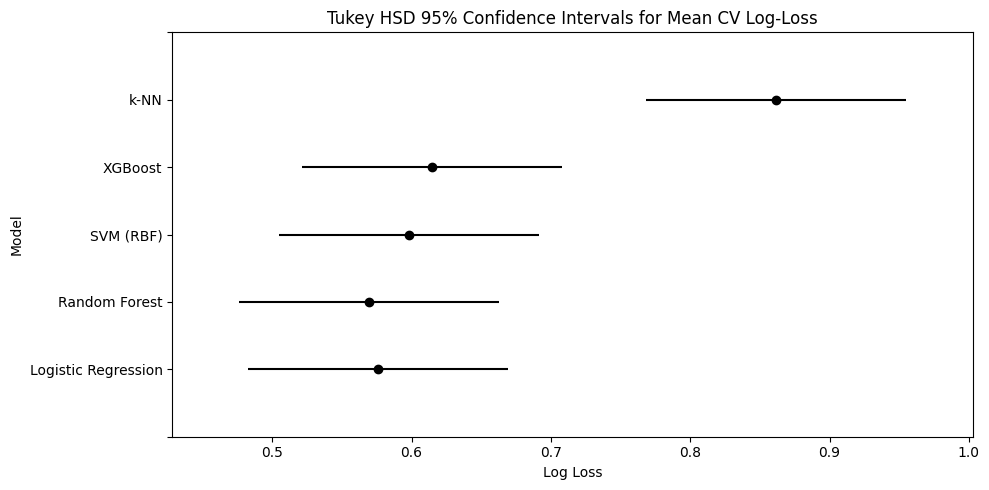

In [115]:
##Tukey HSD Post-Hoc Test

scores_flat = []
labels_flat = []
for name, vals in cv_scores.items():
    scores_flat.extend(vals)
    labels_flat.extend([name] * len(vals))

tukey_models = pairwise_tukeyhsd(scores_flat, labels_flat, alpha=0.05)
print('=== Tukey HSD Post-Hoc Test (CV Log-Loss) ===')
print(tukey_models.summary())

##Visualize Tukey confidence intervals
tukey_models.plot_simultaneous(figsize=(10, 5), xlabel='Log Loss', ylabel='Model')
plt.title('Tukey HSD 95% Confidence Intervals for Mean CV Log-Loss')
plt.tight_layout()
plt.show()

## 16. Final Model Summary & Submission Generation
We select the **best model by CV log-loss** and generate predictions for all 2026 tournament matchups.



In [116]:
##Final ranking table
print('=== FINAL MODEL RANKING ===')
print('\nTest-Set Results (2022–2025):')
print(summary.to_string(float_format='%.4f'))

print('\nCV Results (2010–2021, mean ± std):')
cv_summary = pd.DataFrame({
    'Model': list(cv_scores.keys()),
    'CV Mean Log-Loss': [np.mean(v) for v in cv_scores.values()],
    'CV Std':           [np.std(v)  for v in cv_scores.values()],
}).sort_values('CV Mean Log-Loss')
print(cv_summary.to_string(float_format='%.4f', index=False))

best_model_name = cv_summary.iloc[0]['Model']
print(f'\nBest model (by CV log-loss): {best_model_name}')

=== FINAL MODEL RANKING ===

Test-Set Results (2022–2025):
                 Model  Log Loss  Accuracy  ROC-AUC
1         Seed-Only LR    0.5723    0.7015   0.7715
2  Logistic Regression    0.5732    0.7127   0.7732
3              XGBoost    0.5783    0.6978   0.7689
4                 k-NN    0.5832    0.7090   0.7668
5            SVM (RBF)    0.5833    0.7071   0.7662
6        Random Forest    0.5833    0.6959   0.7668
7          Naive (0.5)    0.6931    0.5000   0.5000

CV Results (2010–2021, mean ± std):
              Model  CV Mean Log-Loss  CV Std
      Random Forest            0.5694  0.0452
Logistic Regression            0.5759  0.0485
          SVM (RBF)            0.5979  0.0519
            XGBoost            0.6147  0.0765
               k-NN            0.8617  0.3092

Best model (by CV log-loss): Random Forest


In [117]:
# Retrain final XGBoost on full training set
xgb_final = xgb.XGBClassifier(
    n_estimators=500, max_depth=4, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss',
    random_state=RANDOM_STATE, verbosity=0
)
xgb_final.fit(X_train_all, y_train)

# ============================================================
# Generate Stage 2 Submission
# ============================================================
sub = pd.read_csv('SampleSubmissionStage2.csv')
sub[['Season','T1','T2']] = sub['ID'].str.split('_', expand=True).astype(int)

# Filter to men's tournament matchups (team IDs in the 1xxx range)
mens_mask = sub['T1'] < 2000
sub_mens = sub[mens_mask].copy().reset_index(drop=True)
print(f'Men\'s matchups: {mens_mask.sum():,}')

# --- Build features directly for men's matchups ---
stat_cols = ['WinPct','PtsFor','PtsAgainst','PointDiff',
             'FG_Pct','FG3_Pct','FT_Pct','OffRebRate','DefRebRate',
             'TORate','Ast','Stl','Blk','OffEff','DefEff','NetEff','OR','DR']

def merge_side(base, team_col, suffix):
    df = base.merge(team_stats[['Season','TeamID'] + stat_cols],
                    left_on=['Season', team_col], right_on=['Season','TeamID'],
                    how='left').drop(columns='TeamID')
    df = df.merge(seeds[['Season','TeamID','SeedNum']],
                  left_on=['Season', team_col], right_on=['Season','TeamID'],
                  how='left').drop(columns='TeamID')
    df = df.merge(elo_df[['Season','TeamID','Elo']],
                  left_on=['Season', team_col], right_on=['Season','TeamID'],
                  how='left').drop(columns='TeamID')
    return df.rename(columns={c: c + suffix for c in stat_cols + ['SeedNum','Elo']})

sf = merge_side(sub_mens, 'T1', '_A')
sf = merge_side(sf,       'T2', '_B')

for col in stat_cols:
    sf[f'd_{col}'] = sf[f'{col}_A'] - sf[f'{col}_B']
sf['d_SeedNum'] = sf['SeedNum_A'] - sf['SeedNum_B']
sf['d_Elo']     = sf['Elo_A']     - sf['Elo_B']
sf['SameConf']  = 0

for col in ALL_FEATURES:
    if sf[col].isna().any():
        sf[col] = sf[col].fillna(matchups[col].median())

X_sub = scaler_all.transform(sf[ALL_FEATURES])
mens_probs = np.clip(xgb_final.predict_proba(X_sub)[:, 1], 0.025, 0.975)

# Build submission file — men's rows get model predictions, remaining rows default to 0.5
final_sub = sub[['ID']].copy()
final_sub['Pred'] = 0.5
final_sub.loc[mens_mask.values, 'Pred'] = mens_probs

final_sub.to_csv('submission_xgboost.csv', index=False)
print(f'Submission saved: submission_xgboost.csv')
print(f'\nPrediction stats:')
print(pd.Series(mens_probs).describe().round(4).to_string())

Men's matchups: 66,430
Submission saved: submission_xgboost.csv

Prediction stats:
count    66430.0000
mean         0.4960
std          0.2381
min          0.0250
25%          0.3092
50%          0.4941
75%          0.6774
max          0.9750


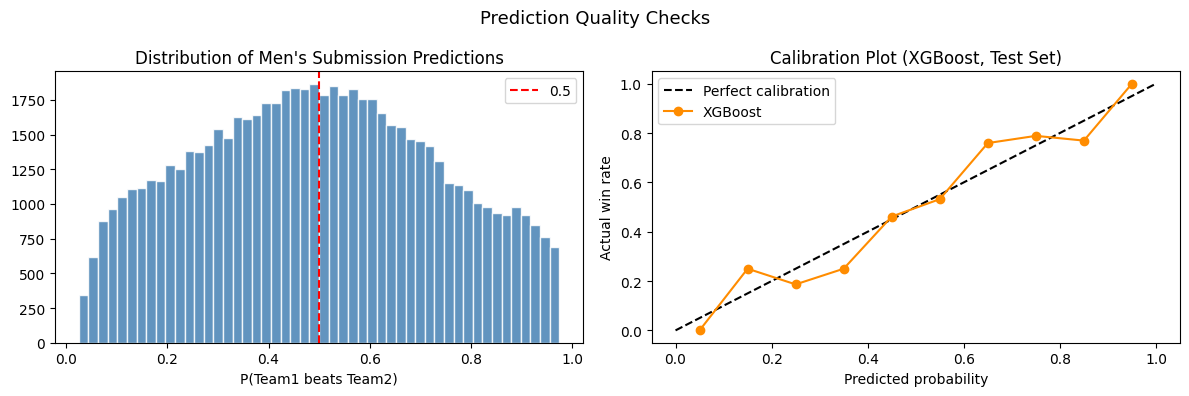


=== Project Complete ===
Artifacts generated:
  submission_xgboost.csv  — Stage 2 submission file

Key findings:
  Best CV model  : Random Forest
  Best Test model: Seed-Only LR (Log Loss 0.5723)


In [118]:
##Prediction distribution sanity check (men's matchups only)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(mens_probs, bins=50, color='steelblue', alpha=0.85, edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', label='0.5')
axes[0].set_title('Distribution of Men\'s Submission Predictions')
axes[0].set_xlabel('P(Team1 beats Team2)')
axes[0].legend()

##Calibration plot: predicted vs actual on test set
bin_edges = np.linspace(0, 1, 11)
bin_mids  = (bin_edges[:-1] + bin_edges[1:]) / 2
y_prob_xgb_clip = np.clip(y_prob_xgb, 0.025, 0.975)
bin_idx   = np.digitize(y_prob_xgb_clip, bin_edges) - 1
bin_idx   = np.clip(bin_idx, 0, len(bin_mids) - 1)
actual_by_bin = [y_test[bin_idx == i].mean() if (bin_idx == i).sum() > 0 else np.nan
                 for i in range(len(bin_mids))]

axes[1].plot([0,1],[0,1], 'k--', label='Perfect calibration')
axes[1].plot(bin_mids, actual_by_bin, 'o-', color='darkorange', label='XGBoost')
axes[1].set_xlabel('Predicted probability')
axes[1].set_ylabel('Actual win rate')
axes[1].set_title('Calibration Plot (XGBoost, Test Set)')
axes[1].legend()

plt.suptitle('Prediction Quality Checks', fontsize=13)
plt.tight_layout()
plt.show()

print('\n=== Project Complete ===')
print('Artifacts generated:')
print('  submission_xgboost.csv  — Stage 2 submission file')
print('\nKey findings:')
print(f'  Best CV model  : {cv_summary.iloc[0]["Model"]}')
print(f'  Best Test model: {summary.iloc[0]["Model"]} (Log Loss {summary.iloc[0]["Log Loss"]:.4f})')